In [1]:
from app.jobs.daily_alarm_job import backfill_alarms_for_year
backfill_alarms_for_year("005930")

Pinged your deployment. You successfully connected to MongoDB!
📆 [005930] 과거 1년치 알람 생성 시작
✅ 데이터 240행 로드됨 (2024-10-21 ~ 2025-10-17)
✅ 60건 알람 생성 완료


In [2]:
from app.db.mongo import user_collection

EMAIL = "user@example.com"   # 대상 사용자 이메일
FAVORITE_CODE = "005930"     # 삼성전자 코드

result = user_collection.update_one(
    {"email": EMAIL},
    {"$addToSet": {"favorites": FAVORITE_CODE}}
)

if result.matched_count == 0:
    print(f"❌ {EMAIL} 사용자를 찾을 수 없습니다.")
else:
    print(f"✅ {EMAIL} 사용자의 favorites에 {FAVORITE_CODE} 추가 완료!")

✅ user@example.com 사용자의 favorites에 005930 추가 완료!


# chat 평가

 "대한항공","삼성전자","에코프로","LG에너지솔루션","오리온","카카오",
        "SK이노베이션","SK하이닉스","현대자동차","기아","한화솔루션","아모레퍼시픽"

In [1]:
import asyncio, pandas as pd, time
from tqdm import tqdm
from app.services.chat_service import ask_llm_gpt  # BALLFiN
from langchain_openai import ChatOpenAI
from app.models.llm.graph import get_investment_reports
import os


gpt = ChatOpenAI(
    model="gpt-4o-mini",
    api_key=os.getenv("OPENAI_API_KEY"),
    streaming = True
    )




# 1️⃣ 최신 이슈형 → 최신 뉴스·실적 전망 이해도, web_search 도구 선택 능력
# 2️⃣ 과거 비교형 → RAG 뉴스 검색 정확도, 과거 사건 인용력
# 3️⃣ 산업 연동형 → 여러 기업·산업 간 관계 추론 능력
# 4️⃣ 시장 전망형 → 거시적 요약·해석력 (LLM reasoning)
# 5️⃣ 뉴스 종합형 → 여러 출처 요약·통합 능력, 맥락 압축력
# 6️⃣ 투자 판단형 → 종합 분석 기반 ‘투자 적합성’ 판단 능력

questions = {
  "삼성전자": [
    "2025년 10월 기준 삼성전자 주가 전망을 요약해줘.",                           # 최신 이슈형
    "삼성전자의 반도체 부문 회복세와 HBM 경쟁 구도를 정리해줘.",                   # 산업 연동형
    "2023년 이후 삼성전자 실적 개선의 주요 요인을 과거 뉴스 중심으로 설명해줘.",       # 과거 비교형
    "지금 시점에서 삼성전자에 투자하는 것이 적절한지, 근거를 들어 분석해줘.",         # 투자 판단형
    "최근 삼성전자 관련 주요 뉴스 3개를 종합 요약해줘."                             # 뉴스 종합형
  ],

  "현대자동차": [
    "2025년 전기차 판매 실적과 글로벌 점유율을 비교해줘.",
    "현대차의 북미 공장 가동률과 IRA(인플레이션감축법) 대응 현황을 분석해줘.",
    "코로나19 이후 현대차의 해외 매출 변화 추세를 요약해줘.",
    "현재 시점에서 현대자동차의 주식은 매수 관점에서 어떤 매력을 가지는지 분석해줘.",
    "최근 현대자동차 관련 뉴스 3개를 투자 관점에서 요약해줘."
  ],

  "LG에너지솔루션": [
    "2025년 10월 기준 LG에너지솔루션의 영업이익 전망을 요약해줘.",
    "북미 공장 증설 및 테슬라 공급망 변화가 실적에 미친 영향을 설명해줘.",
    "리튬 가격 변동이 LG에너지솔루션 실적에 미치는 영향을 과거 사례를 기반으로 설명해줘.",
    "현재 시점에서 LG에너지솔루션은 장기 투자 관점에서 어떤 성장 가능성을 보이나?",
    "최근 LG에너지솔루션 관련 뉴스와 시장 분위기를 종합해 정리해줘."
  ],

  "카카오": [
    "2025년 기준 카카오의 광고 및 커머스 부문 성장세를 요약해줘.",
    "데이터센터 화재 이후 카카오의 서비스 안정성 개선 현황을 설명해줘.",
    "2023년 이후 카카오의 수익구조 변화와 조직개편 흐름을 정리해줘.",
    "현재 시점에서 카카오의 주식은 저평가되어 있는지, 투자 매력을 분석해줘.",
    "최근 카카오 관련 주요 뉴스를 요약하고 기업 전망을 평가해줘."
  ],

  "한화솔루션": [
    "2025년 기준 한화솔루션의 태양광 수출 현황과 IRA 수혜 효과를 분석해줘.",
    "한화큐셀의 미국 내 점유율 변화를 과거 데이터와 함께 설명해줘.",
    "2023~2025년 한화솔루션 매출 추세를 투자 리포트와 뉴스 데이터를 통해 비교해줘.",
    "현재 시점에서 한화솔루션은 에너지 산업 투자 포트폴리오에서 어떤 위치를 차지하는지 분석해줘.",
    "최근 한화솔루션 뉴스 3개를 요약하고 투자 리스크 요인을 정리해줘."
  ],

  "에코프로": [
    "2025년 하반기 에코프로의 실적 전망과 주가 흐름을 요약해줘.",
    "리튬 가격 변동이 에코프로 실적에 어떤 영향을 주었는지 과거 사례와 함께 설명해줘.",
    "에코프로와 LG에너지솔루션의 협력 관계 변화를 시기별로 정리해줘.",
    "지금 에코프로에 신규 투자하는 것이 적절한지, 산업 흐름과 함께 분석해줘.",
    "최근 에코프로 관련 뉴스를 종합해 투자 관점에서 요약해줘."
  ]
}

Pinged your deployment. You successfully connected to MongoDB!
프로젝트 루트 디렉터리: C:\Users\yunji\py\ballpin\BALLFiN-BE
🔄 벡터 DB 초기화 중...


c:\Users\yunji\py\ballpin\BALLFiN-BE\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ 벡터 DB 로드 완료
✅ 인덱스 폴더 'C:\Users\yunji\py\ballpin\BALLFiN-BE\chroma_db'를 로드했습니다.
✅ gpt 에이전트 준비 완료


In [4]:
print(get_investment_reports("LG에너지솔루션"))

📑 MongoDB 리포트 조회: LG에너지솔루션, 최대 5개 (2025년 7월 이후만)
[📅 2025-10-22] LG에너지솔루션
투자의견: BUY, 목표주가: 531000
요약: 2026년 미국 ESS 중심 성장 기대 유럽 EV 수요 대응 (셀 3사 중 가장 빠른 실적 개선)
제공처/작성자: 유안타증권 이안나
----------------------------------------
[📅 2025-10-20] LG에너지솔루션
투자의견: BUY, 목표주가: 531000
요약: 3Q25 Review: 컨센서스 대비 상회하는 실적 기록 2026년, 유럽 EV향 개선 + 미국 ESS 중심 성장 기대
제공처/작성자: 유안타증권 이안나
----------------------------------------
[📅 2025-10-15] LG에너지솔루션
투자의견: 매수, 목표주가: 530000
요약: LG에너지솔루션 목표주가 53만원 유지 급증하는 수요 대응, 추가적인 ESS 라인 전환 진행 중
제공처/작성자: 미래에셋증권 김철중
----------------------------------------
[📅 2025-10-14] LG에너지솔루션
투자의견: BUY, 목표주가: 450000
요약: 3Q25 Review : 보조금 폐지 전 pull-in 효과 없었음에도 이익 개선 테슬라향 소형 전지 출하 증가 및 ESS 배터리 출하 대폭 증가
제공처/작성자: 하나증권 김현수
----------------------------------------
[📅 2025-10-14] LG에너지솔루션
투자의견: 매수, 목표주가: 440000
요약: 3분기 매출액 5.7조원(QoQ+2%, 이하 QoQ), 영업이익 6,013억원(+22%, OPM 10.5%)의 잠정 실적을 발표 영업이익 기준 시장 기대치(5,145억원)와 당사 직전 추정치(5,238억원)를 각각 17%, 15% 상회
제공처/작성자: 신영증권 박진수
----------------------------------------


In [5]:


# ✅ 결과 저장 리스트
results = []

# ✅ 두 모델 응답 수집 함수
async def get_answers(question: str, corp: str):
    """BALLFiN과 GPT 모두의 응답을 받아 리스트에 추가"""
    row = {"corp": corp, "question": question}

    # 1️⃣ BALLFiN Agent
    try:
        bf_ans = await ask_llm_gpt(question)
        row["ballfin_answer"] = bf_ans
    except Exception as e:
        row["ballfin_answer"] = f"[ERROR] {e}"

    # 2️⃣ 일반 GPT
    try:
        gpt_ans = gpt.invoke(question).content
        row["gpt_answer"] = gpt_ans
    except Exception as e:
        row["gpt_answer"] = f"[ERROR] {e}"

    results.append(row)
    return row


# ✅ 전체 질문 루프
async def run_all(sample_n=None):
    """
    모든 기업 질문을 순회하면서 답변을 수집.
    sample_n 지정 시 기업당 n개 질문만 실행.
    """
    for corp, qs in tqdm(questions.items()):
        for i, q in enumerate(qs):
            if sample_n and i >= sample_n:
                break
            print(f"\n[{corp}] Q: {q}")
            row = await get_answers(q, corp)
            print(f"✅ Done ({corp}) | BALLFiN: {len(row['ballfin_answer'])}자 / GPT: {len(row['gpt_answer'])}자")

    # 🔹 CSV로만 저장
    df = pd.DataFrame(results)
    df.to_csv("answers_raw.csv", index=False, encoding="utf-8-sig")
    print("\n💾 저장 완료: answers_raw.csv (시간 제외)")


In [6]:
await run_all()

  0%|          | 0/6 [00:00<?, ?it/s]


[삼성전자] Q: 2025년 10월 기준 삼성전자 주가 전망을 요약해줘.
ask to gpt
📑 MongoDB 리포트 조회: 삼성전자, 최대 5개 (2025년 7월 이후만)
✅ Done (삼성전자) | BALLFiN: 795자 / GPT: 691자

[삼성전자] Q: 삼성전자의 반도체 부문 회복세와 HBM 경쟁 구도를 정리해줘.
ask to gpt
🔍 웹 검색 도구 사용: 삼성전자 반도체 부문 회복세 2025
🔍 웹 검색 도구 사용: 삼성전자 HBM 경쟁 구도 2025
✅ Done (삼성전자) | BALLFiN: 1104자 / GPT: 1179자

[삼성전자] Q: 2023년 이후 삼성전자 실적 개선의 주요 요인을 과거 뉴스 중심으로 설명해줘.
ask to gpt
🔍 RAG 검색 도구 사용: 삼성전자 삼성전자 실적 개선
✅ Done (삼성전자) | BALLFiN: 934자 / GPT: 927자

[삼성전자] Q: 지금 시점에서 삼성전자에 투자하는 것이 적절한지, 근거를 들어 분석해줘.
ask to gpt
📑 MongoDB 리포트 조회: 삼성전자, 최대 5개 (2025년 7월 이후만)
🔍 웹 검색 도구 사용: 삼성전자 주가 환율 금리 2025년 10월
✅ Done (삼성전자) | BALLFiN: 1166자 / GPT: 1093자

[삼성전자] Q: 최근 삼성전자 관련 주요 뉴스 3개를 종합 요약해줘.
ask to gpt
🔍 웹 검색 도구 사용: 삼성전자 최근 뉴스


 17%|█▋        | 1/6 [02:11<10:57, 131.53s/it]

✅ Done (삼성전자) | BALLFiN: 728자 / GPT: 622자

[현대자동차] Q: 2025년 전기차 판매 실적과 글로벌 점유율을 비교해줘.
ask to gpt
🔍 웹 검색 도구 사용: 2025 electric vehicle sales performance global market share
🔍 웹 검색 도구 사용: 2025 전기차 판매 실적 글로벌 점유율
✅ Done (현대자동차) | BALLFiN: 942자 / GPT: 441자

[현대자동차] Q: 현대차의 북미 공장 가동률과 IRA(인플레이션감축법) 대응 현황을 분석해줘.
ask to gpt
🔍 웹 검색 도구 사용: Hyundai North America plant utilization rate 2025
🔍 웹 검색 도구 사용: Hyundai response to Inflation Reduction Act IRA 2025
✅ Done (현대자동차) | BALLFiN: 1273자 / GPT: 1114자

[현대자동차] Q: 코로나19 이후 현대차의 해외 매출 변화 추세를 요약해줘.
ask to gpt
🔍 RAG 검색 도구 사용: 현대자동차 코로나19 이후 현대차의 해외 매출 변화 추세
✅ Done (현대자동차) | BALLFiN: 847자 / GPT: 529자

[현대자동차] Q: 현재 시점에서 현대자동차의 주식은 매수 관점에서 어떤 매력을 가지는지 분석해줘.
ask to gpt
📑 MongoDB 리포트 조회: 현대자동차, 최대 5개 (2025년 7월 이후만)
🔍 웹 검색 도구 사용: Hyundai Motor stock analysis 2025
✅ Done (현대자동차) | BALLFiN: 1439자 / GPT: 1352자

[현대자동차] Q: 최근 현대자동차 관련 뉴스 3개를 투자 관점에서 요약해줘.
ask to gpt
🔍 RAG 검색 도구 사용: 현대자동차 현대자동차


 33%|███▎      | 2/6 [04:27<08:56, 134.10s/it]

...

✅ Done (카카오) | BALLFiN: 881자 / GPT: 711자

[한화솔루션] Q: 2025년 기준 한화솔루션의 태양광 수출 현황과 IRA 수혜 효과를 분석해줘.
ask to gpt
🔍 웹 검색 도구 사용: Hanwha Solutions solar export status 2025
🔍 웹 검색 도구 사용: Hanwha Solutions IRA benefits 2025
✅ Done (한화솔루션) | BALLFiN: 1651자 / GPT: 1185자

[한화솔루션] Q: 한화큐셀의 미국 내 점유율 변화를 과거 데이터와 함께 설명해줘.
ask to gpt
🔍 RAG 검색 도구 사용: 한화솔루션 한화큐셀의 미국 내 점유율 변화
📑 MongoDB 리포트 조회: 한화솔루션, 최대 5개 (2025년 7월 이후만)
✅ Done (한화솔루션) | BALLFiN: 1016자 / GPT: 1057자

[한화솔루션] Q: 2023~2025년 한화솔루션 매출 추세를 투자 리포트와 뉴스 데이터를 통해 비교해줘.
ask to gpt
📑 MongoDB 리포트 조회: 한화솔루션, 최대 5개 (2025년 7월 이후만)
🔍 RAG 검색 도구 사용: 한화솔루션 한화솔루션 매출 추세
✅ Done (한화솔루션) | BALLFiN: 1021자 / GPT: 1018자

[한화솔루션] Q: 현재 시점에서 한화솔루션은 에너지 산업 투자 포트폴리오에서 어떤 위치를 차지하는지 분석해줘.
ask to gpt
📑 MongoDB 리포트 조회: 한화솔루션, 최대 5개 (2025년 7월 이후만)
🔍 웹 검색 도구 사용: 한화솔루션 에너지 산업 투자 포트폴리오 2025
✅ Done (한화솔루션) | BALLFiN: 1054자 / GPT: 997자

[한화솔루션] Q: 최근 한화솔루션 뉴스 3개를 요약하고 투자 리스크 요인을 정리해줘.
ask to gpt
📑 MongoDB 리포트 조회: 한화솔루션, 최대 5개 (2025년 7월 이후만)
🔍 RAG 검색 도구 사용: 한화솔루션 한화솔루션
📑 MongoDB 리포트 

 83%|████████▎ | 5/6 [10:59<02:11, 131.82s/it]

✅ Done (한화솔루션) | BALLFiN: 1044자 / GPT: 879자

[에코프로] Q: 2025년 하반기 에코프로의 실적 전망과 주가 흐름을 요약해줘.
ask to gpt
📑 MongoDB 리포트 조회: 에코프로, 최대 5개 (2025년 7월 이후만)
🔍 웹 검색 도구 사용: 에코프로 2025년 하반기 실적 전망 주가 흐름
✅ Done (에코프로) | BALLFiN: 922자 / GPT: 933자

[에코프로] Q: 리튬 가격 변동이 에코프로 실적에 어떤 영향을 주었는지 과거 사례와 함께 설명해줘.
ask to gpt
🔍 RAG 검색 도구 사용: 에코프로 리튬 가격 변동이 에코프로 실적에 미친 영향
✅ Done (에코프로) | BALLFiN: 806자 / GPT: 826자

[에코프로] Q: 에코프로와 LG에너지솔루션의 협력 관계 변화를 시기별로 정리해줘.
ask to gpt
🔍 RAG 검색 도구 사용: 에코프로 에코프로와 LG에너지솔루션의 협력 관계 변화
🔍 RAG 검색 도구 사용: LG에너지솔루션 에코프로와 LG에너지솔루션의 협력 관계 변화
✅ Done (에코프로) | BALLFiN: 1100자 / GPT: 887자

[에코프로] Q: 지금 에코프로에 신규 투자하는 것이 적절한지, 산업 흐름과 함께 분석해줘.
ask to gpt
📑 MongoDB 리포트 조회: 에코프로, 최대 5개 (2025년 7월 이후만)
🔍 웹 검색 도구 사용: 에코프로 산업 흐름 2025
✅ Done (에코프로) | BALLFiN: 1490자 / GPT: 1122자

[에코프로] Q: 최근 에코프로 관련 뉴스를 종합해 투자 관점에서 요약해줘.
ask to gpt
🔍 RAG 검색 도구 사용: 에코프로 에코프로 관련 최근 뉴스


100%|██████████| 6/6 [13:33<00:00, 135.58s/it]

✅ Done (에코프로) | BALLFiN: 1093자 / GPT: 809자

💾 저장 완료: answers_raw.csv (시간 제외)


# 평가

In [2]:
import pandas as pd, json, asyncio, time
from openai import OpenAI
import os

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))  # 🔑 본인 API 키로 교체

df = pd.read_csv("answers_raw.csv")
print(f"📂 총 {len(df)}개 응답 로드 완료")
df.shape

📂 총 30개 응답 로드 완료


(30, 4)

In [5]:
JUDGE_PROMPT = """
당신은 금융·경제 분석 전문가입니다.
오늘은 2025년 10월 26일 입니다.
아래는 동일한 질문에 대해 두 AI 모델이 작성한 답변입니다.

[질문]
{question}

[모델 A (BALLFiN)]
{answer_a}

[모델 B (GPT-4o-mini)]
{answer_b}

다음 5개 항목을 0~10점으로 평가하세요.
1. 정확성(Accuracy): 금융 뉴스·실적 등 사실과 얼마나 일치하는가
2. 근거 충실도(Faithfulness): 실제 데이터·뉴스 기반으로 보이는가
3. 관련성(Relevance): 질문 의도에 얼마나 부합하는가
4. 환각률(Hallucination): 근거 없는 내용의 비율 (높을 수 록 안좋음)
5. 출처 명시율(Citation): 출처(URL, 기관명 등) 표기 여부

출력은 반드시 JSON 형식으로만 하세요:
{{
  "accuracy": {{"A": float, "B": float}},
  "faithfulness": {{"A": float, "B": float}},
  "relevance": {{"A": float, "B": float}},
  "hallucination": {{"A": float, "B": float}},
  "citation": {{"A": float, "B": float}},
  "winner": "A" or "B",
  "reason": "간단한 요약 이유"
}}
"""


In [6]:
async def judge_llm(question, a, b):
    prompt = JUDGE_PROMPT.format(question=question, answer_a=a, answer_b=b)

    res = client.chat.completions.create(
        model="gpt-4o",
        temperature=0.0,
        messages=[{"role": "user", "content": prompt}]
    )

    text = res.choices[0].message.content.strip()
    print("⚠️ JSON 파싱 실패, 원문 출력:\n", text)
    return {"raw": text}


In [7]:
judged = []

async def run_judge(sample_n=None):
    for i, row in df.iterrows():
        if sample_n and i >= sample_n:
            break

        q = row["question"]
        a = row["ballfin_answer"]
        b = row["gpt_answer"]

        print(f"\n📊 [{i+1}] {row['corp']} - {q[:30]}...")
        score = await judge_llm(q, a, b)
        judged.append({
            "corp": row["corp"],
            "question": q,
            **score
        })
        time.sleep(1)  # API rate-limit 방지

await run_judge()



📊 [1] 삼성전자 - 2025년 10월 기준 삼성전자 주가 전망을 요약해줘....
⚠️ JSON 파싱 실패, 원문 출력:
 ```json
{
  "accuracy": {"A": 8.0, "B": 6.0},
  "faithfulness": {"A": 8.0, "B": 6.0},
  "relevance": {"A": 9.0, "B": 7.0},
  "hallucination": {"A": 2.0, "B": 4.0},
  "citation": {"A": 9.0, "B": 2.0},
  "winner": "A",
  "reason": "모델 A는 구체적인 목표 주가와 증권사들의 의견을 제시하며, 출처를 명확히 밝혀 신뢰성을 높였습니다. 반면, 모델 B는 일반적인 요인들을 나열했으나 구체적인 수치나 출처가 부족하여 상대적으로 덜 구체적입니다."
}
```

📊 [2] 삼성전자 - 삼성전자의 반도체 부문 회복세와 HBM 경쟁 구도를 정...
⚠️ JSON 파싱 실패, 원문 출력:
 ```json
{
  "accuracy": {"A": 8.0, "B": 7.0},
  "faithfulness": {"A": 8.0, "B": 7.0},
  "relevance": {"A": 9.0, "B": 8.0},
  "hallucination": {"A": 2.0, "B": 3.0},
  "citation": {"A": 9.0, "B": 5.0},
  "winner": "A",
  "reason": "모델 A는 구체적인 수치와 출처를 제시하여 정확성과 근거 충실도가 높으며, 질문에 대한 관련성도 더 높습니다. 또한, 출처 명시율이 높아 신뢰성을 더합니다."
}
```

📊 [3] 삼성전자 - 2023년 이후 삼성전자 실적 개선의 주요 요인을 과거...
⚠️ JSON 파싱 실패, 원문 출력:
 ```json
{
  "accuracy": {"A": 8.0, "B": 7.5},
  "faithfulness": {"A": 8.0, "B": 7.0},
  "relevance": {"A": 9

In [13]:
import json
import pandas as pd

def flatten_scores(judged_list):
    rows = []
    for j in judged_list:
        base = {"corp": j["corp"], "question": j["question"]}
        raw_text = j.get("raw", "").strip()

        # 백틱 제거 후 JSON 파싱
        if raw_text.startswith("```json"):
            raw_text = raw_text.replace("```json", "").replace("```", "").strip()

        try:
            score = json.loads(raw_text)
        except Exception:
            print("⚠️ JSON 파싱 실패:", j["corp"], j["question"])
            continue

        # 기본 평가 항목
        metrics = ["accuracy", "faithfulness", "relevance", "hallucination", "citation"]
        for m in metrics:
            base[f"{m}_A"] = score.get(m, {}).get("A", None)
            base[f"{m}_B"] = score.get(m, {}).get("B", None)

        base["winner"] = score.get("winner", None)
        base["reason"] = score.get("reason", None)
        rows.append(base)

    return pd.DataFrame(rows)




In [14]:
df_judged = flatten_scores(judged)
df_judged.to_csv("judged_results.csv", index=False, encoding="utf-8-sig")

print("💾 judged_results.csv 저장 완료")
display(df_judged.head())

# 🔹 A/B 평균 점수 계산
metrics = ["accuracy", "faithfulness", "relevance", "hallucination", "citation"]
summary = (
    df_judged[[f"{m}_A" for m in metrics] + [f"{m}_B" for m in metrics]]
    .mean()
    .round(2)
)
summary

💾 judged_results.csv 저장 완료


,corp,question,accuracy_A,accuracy_B,faithfulness_A,faithfulness_B,relevance_A,relevance_B,hallucination_A,hallucination_B,citation_A,citation_B,winner,reason
0,삼성전자,2025년 10월 기준 삼성전자 주가 전망을 요약해줘.,8.0,6.0,8.0,6.0,9.0,7.0,2.0,4.0,9.0,2.0,A,"모델 A는 구체적인 목표 주가와 증권사들의 의견을 제시하며, 출처를 명확히 밝혀 신..."
1,삼성전자,삼성전자의 반도체 부문 회복세와 HBM 경쟁 구도를 정리해줘.,8.0,7.0,8.0,7.0,9.0,8.0,2.0,3.0,9.0,5.0,A,"모델 A는 구체적인 수치와 출처를 제시하여 정확성과 근거 충실도가 높으며, 질문에 ..."
2,삼성전자,2023년 이후 삼성전자 실적 개선의 주요 요인을 과거 뉴스 중심으로 설명해줘.,8.0,7.5,8.0,7.0,9.0,8.5,2.0,3.0,9.0,5.0,A,"모델 A는 구체적인 출처를 명시하고 있으며, 삼성전자의 실적 개선 요인에 대한 설명..."
3,삼성전자,"지금 시점에서 삼성전자에 투자하는 것이 적절한지, 근거를 들어 분석해줘.",7.5,8.0,7.0,8.0,8.5,8.5,3.0,2.0,8.0,5.0,B,"모델 B는 삼성전자의 재무 건전성, 반도체 시장 동향, 스마트폰 및 가전제품, 지속..."
4,삼성전자,최근 삼성전자 관련 주요 뉴스 3개를 종합 요약해줘.,8.0,7.0,8.0,7.0,9.0,8.0,2.0,3.0,9.0,5.0,A,"모델 A는 출처를 명확히 제시하고 있으며, 뉴스의 정확성과 관련성 측면에서 더 높은..."


accuracy_A         7.80
faithfulness_A     7.72
relevance_A        8.85
hallucination_A    2.30
citation_A         8.32
accuracy_B         6.83
faithfulness_B     6.63
relevance_B        7.90
hallucination_B    3.32
citation_B         3.90
dtype: float64

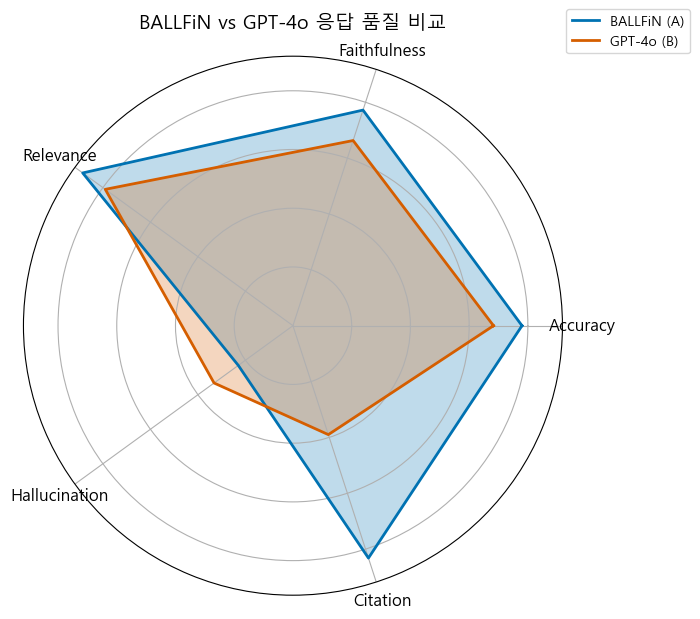

In [21]:
import matplotlib.pyplot as plt
import numpy as np
#한글깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'

# 평균값 준비
values_A = [summary[f"{m}_A"] for m in metrics]
values_B = [summary[f"{m}_B"] for m in metrics]

# 각 지표별 라벨
labels = [m.capitalize() for m in metrics]
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
values_A += values_A[:1]  # 폐곡선
values_B += values_B[:1]
angles += angles[:1]

# 스파이더 차트 생성
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

ax.plot(angles, values_A, linewidth=2, linestyle="-", label="BALLFiN (A)", color="#0072B2")
ax.fill(angles, values_A, alpha=0.25, color="#0072B2")

ax.plot(angles, values_B, linewidth=2, linestyle="-", label="GPT-4o (B)", color="#D55E00")
ax.fill(angles, values_B, alpha=0.25, color="#D55E00")

# 스타일링
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=12)
ax.set_yticklabels([])
ax.set_title("BALLFiN vs GPT-4o 응답 품질 비교", size=14, pad=20)


ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))

plt.show()
